# **Programming Assignment 1: Naive Bayes**


### Name: Musa Kashif
### Roll Number: 28100244



## **Learning Outcomes**
After completing this PA, you should be able to:
- Choose Naive Bayes variant based on feature type

- Implement Naive Bayes in log-space  

- Design a Bag-of-Words (BoW) vectorizer  

- Evaluate models with macro metrics  

- Compare implementations with scikit-learn
<br>

## **Introduction**
In this notebook, you will be implementing two types of Naive Bayes model based on the dataset features and task requirements.

For reference and additional details on these topics, please go through [Appendix B](https://web.stanford.edu/~jurafsky/slp3/) of the SLP3 book.

In this assignment, you are provided with two datasets. One is suitable for **Bernoulli Naive Bayes**, while the other is appropriate for **Multinomial Naive Bayes**. Your task is to:
1. Analyze both datasets and determine which Naive Bayes model to apply based on the dataset’s characteristics.

2. Implement both **Bernoulli** and **Multinomial Naive Bayes** from scratch, adhering to the guidelines below regarding allowed libraries.

3. Finally, apply the corresponding models using the `sklearn` library and compare the results with your own implementation.
<br>

## **Import Policy Clarification**
To keep the assignment consistent and fair, please follow these rules for imports:

- **From-scratch sections**:  
  - Allowed: `numpy`, `pandas`, and Python standard library (e.g., `import re`)
  
  - Do **not** use `sklearn` or any other ML libraries.

- **Evaluation (anywhere in the notebook)**:  
  - Allowed: `sklearn.metrics` (e.g., `accuracy_score`, `precision_score`, `recall_score`, etc.)

- **Baselines section only**:  
  - Allowed: `sklearn.naive_bayes` (specifically `BernoulliNB` and `MultinomialNB`)  

**No additional imports** are permitted beyond the scope listed above.
<br><br>

## **Instructions**
- Follow along with the notebook, filling out the necessary code where instructed.

- <span style="color: red;">Make sure to run all cells for credit.</span>

- <span style="color: red;">Do not remove any pre-written code.</span>

- <span style="color: red;">Feel free to insert additional code cells.</span>

- <span style="color: red;">You must attempt all parts.</span>

**All necessary libraries for this assignment have already been added. You are not allowed to add any additional imports.**

In [67]:
# uncomment the following line if scikit-learn not installed already
!pip install  scikit-learn

!pip install numpy regex pandas
import numpy as np
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## **1. Understanding and Loading The Datasets [3 Marks]**
In this assignment, you are provided with two datasets:

- **Golf**: The Golf Dataset records various weather and environmental conditions alongside the decision of whether to play golf on a given day. It includes features such as Outlook, Temperature, Humidity, Windy conditions, and whether it is a Holiday, as well as the target variable Play, indicating if golf was played (yes/no). You may find this data in the file `golf_data.csv` in the resources provided with this assignment.

- **20 Newsgroups**: The 20 Newsgroups dataset is a classic benchmark for text classification, consisting of approximately 20,000 newsgroup posts spread across 20 different discussion groups covering topics such as politics, religion, science, technology, sports, and more. The Kaggle version provides individual `.txt` files for each newsgroup along with a `list.csv` index file. Read more about the dataset [here](https://www.kaggle.com/datasets/crawford/20-newsgroups). In this assignment you will consolidate these files into a single DataFrame and select a subset of 5 categories for training and testing.

Before we begin, explore both datasets and identify their key features. This will help you determine which dataset is best suited for **Bernoulli Naive Bayes** and which is better suited for **Multinomial Naive Bayes**. Load both datasets using `pandas` and print the first 5 rows.


### 1.1 Loading the Golf Dataset
As the dataset is contained within a single `.csv` file, you may load the dataset using a `read_csv()` call. Afterwards, print the first five rows to verify that the load was successful.

In [68]:
# Golf Dataset
# Code Here
golf_data = pd.read_csv('golf_data.csv')

In [69]:
# Print the first 5 rows
golf_data.head()

,Holiday,Month,Season,Temperature,Humidity,Windy,Outlook,Crowdedness,Play
0,1,Winter,Winter,low,low,1,sunny,high,1
1,1,Winter,Winter,low,low,1,sunny,high,0
2,1,Winter,Winter,low,low,1,sunny,high,0
3,1,Winter,Winter,low,low,1,sunny,high,1
4,1,Winter,Winter,low,low,1,sunny,high,1


### 1.2 Loading the 20 Newsgroups Dataset

The Kaggle download provides the data as **separate `.txt` files** — one per newsgroup — where each file contains all documents for that group delimited by metadata lines (`Newsgroup:`, `document_id:`, `From:`, `Subject:`).

We begin by consolidating these files into a single pandas DataFrame with two columns:
- `text`: the content of each document

- `newsgroup`: the category label

We will then **select 5 categories** to keep the problem manageable.

The 5 selected categories are:
- `rec.sport.baseball`

- `sci.space`

- `talk.politics.mideast`

- `comp.graphics`

- `sci.med`

These give a nice spread across sports, science, politics, and technology.


In [70]:

import glob
import os

print(os.listdir())

# --- Starter Code: Consolidating the 20 Newsgroups .txt files into a DataFrame ---

DATASET_DIR = 'data'  # Update this path if your extracted folder has a different name

SELECTED_GROUPS = [
    'rec.sport.baseball',
    'sci.space',
    'talk.politics.mideast',
    'comp.graphics',
    'sci.med'
]

def parse_newsgroup_file(filepath):
    """
    Parse a single newsgroup .txt file and return a list of (text, newsgroup) tuples.
    Each document in the file starts with 'Newsgroup: <name>' and 'document_id: <id>'.
    We extract everything after the Subject: line as the document text.
    """
    documents = []
    with open(filepath, encoding='latin-1') as f:
        content = f.read()

    # Split on the 'Newsgroup:' delimiter (each doc starts with this)
    raw_docs = content.split('Newsgroup: ')

    for raw_doc in raw_docs[1:]:  # skip the first empty split
        lines = raw_doc.strip().split('\n')
        newsgroup = lines[0].strip()

        # Find where the header ends (after Subject: line) and body begins
        body_start = 0
        for idx, line in enumerate(lines):
            if line.startswith('Subject:'):
                body_start = idx + 1
                break

        body = '\n'.join(lines[body_start:]).strip()
        if len(body) > 20:  # skip very short/empty docs
            documents.append((body, newsgroup))

    return documents

# Parse only the selected newsgroup files
all_docs = []
for group in SELECTED_GROUPS:
    filepath = os.path.join(DATASET_DIR, f'{group}.txt')
    if os.path.exists(filepath):
        docs = parse_newsgroup_file(filepath)
        all_docs.extend(docs)
        print(f"Loaded {len(docs)} documents from {group}")
    else:
        print(f"WARNING: File not found: {filepath}")

# Build the DataFrame
news_df = pd.DataFrame(all_docs, columns=['text', 'newsgroup'])
print(f"\nTotal documents: {len(news_df)}")
print(f"\nClass distribution:\n{news_df['newsgroup'].value_counts()}")

['.config', 'README.txt', 'golf_data.csv', 'data', 'english_stopwords.txt', '.ipynb_checkpoints', 'sample_data']
Loaded 1982 documents from rec.sport.baseball
Loaded 1970 documents from sci.space
Loaded 1876 documents from talk.politics.mideast
Loaded 1944 documents from comp.graphics
Loaded 1970 documents from sci.med

Total documents: 9742

Class distribution:
newsgroup
rec.sport.baseball       1982
sci.space                1970
sci.med                  1970
comp.graphics            1944
talk.politics.mideast    1876
Name: count, dtype: int64


In [71]:
# Print the first 5 rows
print(news_df.head())

                                                text           newsgroup
0  The Orioles' pitching staff again is having a ...  rec.sport.baseball
1  From: smith@ms.uky.edu (Brian Smith)\n\nIn art...  rec.sport.baseball
2  Hell, the Orioles' Opening Day game could easi...  rec.sport.baseball
3  There's a lot of whining about how much player...  rec.sport.baseball
4  In article <1993Apr5.173500.26383@ra.msstate.e...  rec.sport.baseball


##### **Before proceeding with further tasks, ensure you have determined which type of Naive Bayes is most suitable for each dataset.**

## **2. Data Preprocessing [10 Marks]**
Before applying Naive Bayes, both datasets require preprocessing to convert the raw data into a format suitable for probabilistic learning. This helps us ensure that the data aligns with the assumptions of Bernoulli and Multinomial Naive Bayes and allows for effective training and evaluation of the models.


### 2.1 Preprocessing the Golf Dataset
The Golf dataset contains categorical information, which, while useful to a human reader, cannot be directly processed. Before we proceed, we will need to preprocess the file by applying one-hot encoding to the columns of the Golf dataset. You may use `pd.get_dummies()` as part of this task.



In [72]:
# Code Here
print("Original Golf dataset:")
print(golf_data.head())

# Apply one-hot encoding to all categorical columns
golf_encoded = pd.get_dummies(golf_data, drop_first=False)

Original Golf dataset:
   Holiday   Month  Season Temperature Humidity  Windy Outlook Crowdedness  \
0        1  Winter  Winter         low      low      1   sunny        high   
1        1  Winter  Winter         low      low      1   sunny        high   
2        1  Winter  Winter         low      low      1   sunny        high   
3        1  Winter  Winter         low      low      1   sunny        high   
4        1  Winter  Winter         low      low      1   sunny        high   

   Play  
0     1  
1     0  
2     0  
3     1  
4     1  


Print the first five data samples after preprocessing.

In [73]:
# Code Here
print("\nGolf dataset after one-hot encoding:")
print(golf_encoded.head())


Golf dataset after one-hot encoding:
   Holiday  Windy  Play  Month_Non-Winter  Month_Winter  Season_Non-Winter  \
0        1      1     1             False          True              False   
1        1      1     0             False          True              False   
2        1      1     0             False          True              False   
3        1      1     1             False          True              False   
4        1      1     1             False          True              False   

   Season_Winter  Temperature_high  Temperature_low  Humidity_high  \
0           True             False             True          False   
1           True             False             True          False   
2           True             False             True          False   
3           True             False             True          False   
4           True             False             True          False   

   Humidity_low  Outlook_not sunny  Outlook_sunny  Crowdedness_high  \
0

#### 2.1.1 Train-Test Split

After encoding, we need to split the data into training and test sets using [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) from `sklearn`. Make sure to set the parameter `test_size = 0.3`, which means that 30% of the data will be reserved for testing and the remaining 70% for training the model.

*Tip:* It is helpful to print the **shape of the dataset before splitting** and the **shapes of the training and test sets after splitting**. This will let you confirm that the split has been done correctly.

In [74]:
# Code Here
from sklearn.model_selection import train_test_split

# Assume the last column is the target (e.g., 'PlayGolf') and the rest are features
X = golf_encoded.iloc[:, :-1]  # Features
y = golf_encoded.iloc[:, -1]   # Target

print("Shape of the dataset before splitting:")
print("X:", X.shape)
print("y:", y.shape)

# Split into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nShape of training and test sets:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Shape of the dataset before splitting:
X: (7665, 14)
y: (7665,)

Shape of training and test sets:
X_train: (5365, 14)
X_test: (2300, 14)
y_train: (5365,)
y_test: (2300,)


### 2.2 Preprocessing the 20 Newsgroups Dataset
At this stage, you need to pre-process the 20 Newsgroups text data to ensure it is in a format suitable for further analysis. Newsgroup posts tend to be messier than news articles — they contain email headers, quoted replies, signatures, and other artifacts.

The following steps should be performed:

- Remove any URLs.

- Remove email addresses.

- Remove punctuation and non-alphanumeric characters.

- Convert all text to lowercase.

- Remove any extra whitespace.

- Eliminate common stopwords.

- Remove common newsgroup header artifacts (e.g., lines starting with `From:`, `Subject:`, `Organization:`, `Lines:`, `Path:`, etc.)

In the cell below, implement a function that carries out these tasks. You can use `english_stopwords.txt` for removing stopwords.

*Note:* Stopwords are very common words (such as *the, is, and, in, of*) that occur frequently in text but usually do not add much meaning for tasks like classification. Removing stopwords helps reduce noise in the data and makes the model focus on the more informative words.

Once the function is complete, apply it to the `text` column of your 20 Newsgroups DataFrame to obtain the preprocessed text.

*Tip:* Use different variable names from the variables you used in 2.1 so they don't get overwritten.


In [75]:
# Code Here
# Load stopwords from the file
with open('english_stopwords.txt', 'r') as f:
    stopwords = set(f.read().splitlines())

# Define the preprocessing function
def preprocess_newsgroup_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove common newsgroup header artifacts
    headers = ['From:', 'Subject:', 'Organization:', 'Lines:', 'Path:']
    for header in headers:
        text = re.sub(r'^' + re.escape(header) + r'.*$', '', text, flags=re.MULTILINE)

    # Remove punctuation and non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stopwords])

    return text

# Apply preprocessing to the 20 Newsgroups DataFrame
news_df['clean_text'] = news_df['text'].apply(preprocess_newsgroup_text)

Print the first 5 data samples after preprocessing.


In [76]:
# Code Here
print(news_df[['text', 'clean_text']].head(5))

                                                text  \
0  The Orioles' pitching staff again is having a ...   
1  From: smith@ms.uky.edu (Brian Smith)\n\nIn art...   
2  Hell, the Orioles' Opening Day game could easi...   
3  There's a lot of whining about how much player...   
4  In article <1993Apr5.173500.26383@ra.msstate.e...   

                                          clean_text  
0  orioles pitching staff fine exhibition season ...  
1  article david tate writes read followups thoug...  
2  hell orioles opening day game could easily lar...  
3  lot whining much players overpaid thought put ...  
4  article jiann ming su writes say buy henderson...  


#### 2.2.1 Train-Test Split

Split the preprocessed 20 Newsgroups data into training and test sets using `train_test_split()` with `test_size=0.25` and `random_state=42`. This gives you approximately 7,000 training samples and 2,400 test samples across 5 categories.


In [77]:
# Code Here
X_news = news_df['clean_text']   # Preprocessed text
y_news = news_df['newsgroup']    # Labels

print("Shape before splitting:")
print("X_news:", X_news.shape)
print("y_news:", y_news.shape)

# Split into training (75%) and test (25%)
X_train_news, X_test_news, y_train_news, y_test_news = train_test_split(
    X_news, y_news, test_size=0.25, random_state=42, stratify=y_news
)

print("\nShape after splitting:")
print("X_train_news:", X_train_news.shape)
print("X_test_news:", X_test_news.shape)
print("y_train_news:", y_train_news.shape)
print("y_test_news:", y_test_news.shape)

Shape before splitting:
X_news: (9742,)
y_news: (9742,)

Shape after splitting:
X_train_news: (7306,)
X_test_news: (2436,)
y_train_news: (7306,)
y_test_news: (2436,)


## **3. Implementing Bernoulli Naive Bayes from Scratch** [25 Marks]

We are now set up to implement Naive Bayes classifiers from scratch.

### 3.1 Understanding Bernoulli Naive Bayes
Recall that the Bernoulli Naive Bayes model is based on **Bayes' Theorem**:

$$
P(y \mid x) = \frac{P(x \mid y)P(y)}{P(x)}
$$

What we really want is to find the class \(c\) that maximizes $P(c \mid x)$, so we can use the following equation:

$$
\hat{c} = \underset{c}{\text{argmax}} \ P(c \mid x) = \underset{c}{\text{argmax}} \ P(x \mid c)P(c)
$$

In the case of **Bernoulli Naive Bayes**, we assume that each word \($x_i$\) in a sentence follows a **Bernoulli distribution**, meaning that the word either appears (1) or does not appear (0) in the document. We can simplify the formula using this assumption:

$$
\hat{c} = \underset{c}{\text{argmax}} \ P(c) \prod_{i=1}^{n} P(x_i = 1 \mid c)^{x_i} P(x_i = 0 \mid c)^{1 - x_i}
$$

Where:

- $x_i = 1$ if the $i^{\text{th}}$ word is present in the document.
- $x_i = 0$ if the $i^{\text{th}}$ word is not present in the document.


We can estimate $P(c)$ by counting the number of times each class appears in our training data, and dividing by the total number of training examples. We can estimate $P(x_i = 1 \mid c)$ by counting the number of documents in class $c$ that contain the word $x_i$, and dividing by the total number of documents in class $c$.

### **Important: Laplace Smoothing**

When calculating $P(x_i = 1 \mid c)$ and $P(x_i = 0 \mid c)$, we apply **Laplace smoothing** to avoid zero probabilities. This is essential because, without it, any word that has not appeared in a document of class $c$ will have a probability of zero, which would make the overall product zero, leading to incorrect classification.

**Reason**: Laplace smoothing ensures that we don't encounter zero probabilities by adding a small constant (typically 1) to both the numerator and the denominator. This is particularly useful when a word has never appeared in the training data for a specific class.

The smoothed probability formula is:

$$
P(x_i = 1 \mid c) = \frac{\text{count of documents in class } c \text{ where } x_i = 1 + 1}{\text{total documents in class } c + 2}
$$

This ensures no word has a zero probability, even if it was unseen in the training data.

### **Avoiding Underflow with Logarithms:**

To avoid underflow errors due to multiplying small probabilities, we apply logarithms, which convert the product into a sum:

$$
\hat{c} = \underset{c}{\text{argmax}} \ \log P(c) + \sum_{i=1}^{n} \left[ x_i \log P(x_i = 1 \mid c) + (1 - x_i) \log P(x_i = 0 \mid c) \right]
$$

You will now implement this algorithm.

<span style="color: red;"> For this part, the only external library you will need is `numpy`.</span>


### 3.2 Implementing Bernoulli Naive Bayes [25 Marks]
We have provided a class definition for `BernoulliNaiveBayes` below. Your task is to complete the methods so that the class can learn from training data and make predictions on new data.

### 1. `__init__`  
This method sets up the model. It creates empty containers that will later hold:  
- the probabilities of each class (class priors)

- the probabilities of features given each class

At this stage, no calculations are done — it’s just preparation.


### 2. `model_fit(X_train, y_train)`  
This method is where the model learns from the training data.  

It figures out:  
- how likely each class is overall

- how likely each feature is to appear (or not) when the data belongs to a certain class

These probabilities are estimated from the training data, with a small adjustment (Laplace smoothing) so that unseen features don’t break the model.  

After this step, the model has all the information it needs for making predictions.

### 3. `model_predict(X_test)`  
This method uses the probabilities learned during training to classify new examples.  

For each new input, the model:  
- calculates how likely it is to belong to each possible class

- chooses the class with the highest likelihood

This is how the model turns what it learned into actual predictions.

**In short,**
- `__init__`: prepare storage for probabilities.  
- `model_fit`: learn probabilities from training data.  
- `model_predict`: apply those probabilities to classify new data.

In [78]:
import numpy as np

class BernoulliNaiveBayes:
    def __init__(self):
        self.classes = None
        self.class_priors = {}
        self.feature_probs = {}

    def model_fit(self, X_train, y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)

        self.classes = np.unique(y_train)
        num_features = X_train.shape[1]
        num_samples = X_train.shape[0]

        for c in self.classes:
            # Boolean mask for samples of class c
            X_c = X_train[y_train == c]
            n_c = X_c.shape[0]

            # Class prior with Laplace smoothing
            self.class_priors[c] = n_c / num_samples

            # Feature probabilities with Laplace smoothing
            # P(x_i = 1 | c) = (count of docs where x_i = 1 in class c + 1) / (n_c + 2)
            probs = (np.sum(X_c, axis=0) + 1) / (n_c + 2)
            self.feature_probs[c] = probs


    def model_predict(self, X_test):

        X_test = np.array(X_test)
        num_samples = X_test.shape[0]
        predictions = []

        for i in range(num_samples):
            x = X_test[i]
            class_scores = {}

            for c in self.classes:
                probs = self.feature_probs[c]

                # Bernoulli Naive Bayes log-likelihood
                log_likelihood = np.sum(x * np.log(probs) + (1 - x) * np.log(1 - probs))

                # Add log prior
                log_likelihood += np.log(self.class_priors[c])

                class_scores[c] = log_likelihood

            # Predict the class with the highest log-likelihood
            predicted_class = max(class_scores, key=class_scores.get)
            predictions.append(predicted_class)

        return np.array(predictions)

### 3.3 Utilising the Model
After completing the class definition, you need to train the model on the training data you processed earlier. This will then allow your model to generate predictions on new, unseen data.

1. **Train the model**  
   - Create an object of your `BernoulliNaiveBayes` class.  
   - Call the `.model_fit()` method on your training data (`X_train`, `y_train`).  

2. **Generate predictions**  
   - Use the `.model_predict()` method on your test data (`X_test`).  
   - Store the predicted labels in `y_pred`.

In [79]:
# Code here
# 1. Build a vocabulary from training data
vocab = {}
for doc in X_train_news:
    for word in doc.split():
        if word not in vocab:
            vocab[word] = len(vocab)  # assign a unique index to each word

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# 2. Function to convert text to binary feature vector
def text_to_binary_vector(text, vocab):
    vector = np.zeros(len(vocab), dtype=int)
    for word in text.split():
        if word in vocab:
            vector[vocab[word]] = 1
    return vector

# 3. Convert training and test sets to binary feature matrices
X_train_bin = np.array([text_to_binary_vector(doc, vocab) for doc in X_train_news])
X_test_bin = np.array([text_to_binary_vector(doc, vocab) for doc in X_test_news])

# Labels
y_train_bin = np.array(y_train_news)
y_test_bin = np.array(y_test_news)

# 4. Train the model
bnb_model = BernoulliNaiveBayes()
bnb_model.model_fit(X_train_bin, y_train_bin)

# 5. Predict on test set
y_pred = bnb_model.model_predict(X_test_bin)

# Optional: print first 10 predictions vs actual labels
for pred, actual in zip(y_pred[:10], y_test_bin[:10]):
    print(f"Predicted: {pred}, Actual: {actual}")

Vocabulary size: 46843
Predicted: sci.space, Actual: sci.space
Predicted: sci.space, Actual: sci.space
Predicted: comp.graphics, Actual: comp.graphics
Predicted: sci.space, Actual: sci.space
Predicted: comp.graphics, Actual: comp.graphics
Predicted: talk.politics.mideast, Actual: talk.politics.mideast
Predicted: rec.sport.baseball, Actual: rec.sport.baseball
Predicted: comp.graphics, Actual: comp.graphics
Predicted: comp.graphics, Actual: sci.space
Predicted: rec.sport.baseball, Actual: rec.sport.baseball


### 3.4 Evaluate the Model
The code to calculate evaluation metrics and display the confusion matrix has been provided to you. All you need to do is replace the dummy variables in the code with your actual ones:  
- `y_test` → the true labels from your test set.

- `y_pred` → the labels predicted by your model.  

The code will then automatically compute **Accuracy**,  **Precision**,  **Recall**,  **F1 Score**,  and display the **Confusion Matrix** for your results.

For now, just remember:  
- **The higher these scores are, the better your model is performing.**  
- Each metric should be at least **80% or higher** on the validation data.  


Accuracy: 0.9006568144499179
Precision: 0.9222346344695801
Recall: 0.8989107548650324
F1 Score: 0.9007796492980986
Confusion Matrix:
[[473  11   2   0   0]
 [  0 496   0   0   0]
 [ 13  36 443   1   0]
 [ 22  21   1 448   0]
 [  6 115  10   4 334]]


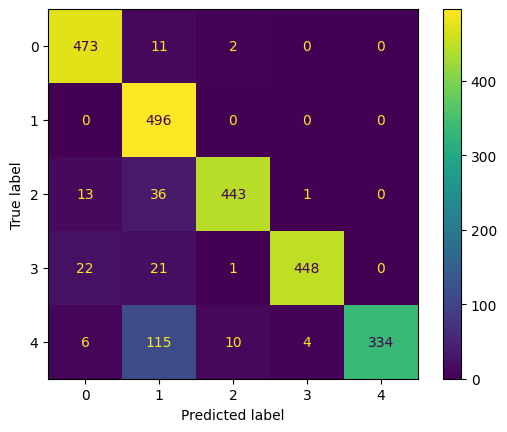

In [80]:
# Replace y_test and y_pred with your test variables

accuracy = accuracy_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred, average='macro')
recall = recall_score(y_test_bin, y_pred, average='macro')
f1 = f1_score(y_test_bin, y_pred, average='macro')
matrix = confusion_matrix(y_test_bin, y_pred)
matrix_display = ConfusionMatrixDisplay(matrix)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
matrix_display.plot()
print(matrix)

## **4. Implementing Multinomial Naive Bayes from Scratch** [37 Marks]

In this section, you will implement Multinomial Naive Bayes from scratch on the **20 Newsgroups** dataset (5 selected categories).

### 4.1 Vectorizing sentences with Bag of Words [7 Marks]

Now that we have loaded in our data, we will need to vectorize our sentences - this is necessary to be able to numericalize our inputs before feeding them into our model.

We will be using a Bag of Words approach to vectorize our sentences. This is a simple approach that counts the number of times each word appears in a sentence.

The element at index $\text{i}$ of the vector will be the number of times the $\text{i}^{\text{th}}$ word in our vocabulary appears in the sentence. So, for example, if our vocabulary is `["the", "cat", "sat", "on", "mat"]`, and our sentence is `"the cat sat on the mat"`, then our vector will be `[2, 1, 1, 1, 1]`.

You will now create a `BagOfWords` class to vectorize our sentences. This will involve creating

1. A vocabulary from our corpus

2. A mapping from words to indices in our vocabulary

3. A function to vectorize a sentence in the fashion described above

It may help you to define something along the lines of a `fit` and a `vectorize` method.

- **`fit(sentences)`**: This method should look at all the sentences in your dataset and build up a vocabulary. It also creates a mapping from each word to its index in the vocabulary.  

- **`vectorize(sentence)`**: This method takes a single sentence and converts it into a Bag of Words vector, using the vocabulary created in `fit`. Each position in the vector corresponds to a word in the vocabulary, and the value is the count of how many times that word appears in the sentence.

In [81]:
class BagOfWords:
    def __init__(self, max_vocab=2000):
        self.vocab = []        # ordered list of words
        self.word2idx = {}
        self.max_vocab = max_vocab


    def fit(self, sentences):
        word_counts = {}
        for sentence in sentences:
            for word in sentence.split():
                if word in word_counts:
                    word_counts[word] += 1
                else:
                    word_counts[word] = 1

        # Sort by frequency (descending) and keep top max_vocab words
        sorted_words = sorted(word_counts, key=lambda w: word_counts[w], reverse=True)
        top_words = sorted_words[:self.max_vocab]

        self.vocab = top_words
        self.word2idx = {word: idx for idx, word in enumerate(self.vocab)}

    def vectorize(self, sentence):
        vector = [0] * len(self.vocab)
        for token in sentence.split():
            if token in self.word2idx:
                vector[self.word2idx[token]] += 1
        return vector


For a sanity check, you can manually set the vocabulary of your `BagOfWords` object to the vocabulary of the example above, and check that the vectorization of the sentence is correct.

Once you have implemented the `BagOfWords` class, fit it to the **training data**, and vectorize both the training and test data.

*Note:* The 20 Newsgroups vocabulary can be very large. Consider limiting your vocabulary to the top **2000 most frequent words** across the training corpus to keep things computationally manageable. You can do this inside your `fit` method by sorting words by frequency and keeping only the top-K.

In [82]:
# Code Here — Sanity check
bow_test = BagOfWords()
bow_test.vocab = ["hello", "world", "foo", "bar", "baz"]
bow_test.word2idx = {w: i for i, w in enumerate(bow_test.vocab)}

bow_test.vocab_size = len(bow_test.vocab)
# Sample sentence
test_sentence = "hello foo hello baz"
test_vector = bow_test.vectorize(test_sentence)

print(f"Vocabulary: {bow_test.vocab}")
print(f"Sentence: '{test_sentence}'")
print(f"Vector: {test_vector}")  # Expected: [2, 0, 1, 0, 1]

Vocabulary: ['hello', 'world', 'foo', 'bar', 'baz']
Sentence: 'hello foo hello baz'
Vector: [2, 0, 1, 0, 1]


In [83]:
print(type(X_train_news))
print(type(X_test_news))
print(X_train_news.iloc[0][:100])
print(X_test_news.iloc[0][:100])

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
portugese launch complex wonderful portuguese launch complex gosh polish american way portuguese bra
current orbital elements norad two line element sets carried celestial bbs 513 427 0674 updated dail


In [84]:
# Code Here — Fit BagOfWords on training data
X_train_list = X_train_news.tolist()
X_test_list = X_test_news.tolist()

bow = BagOfWords()
bow.fit(X_train_news)

print(f"Vocabulary size: {len(bow.vocab)}")
print(f"Sample vocabulary words: {bow.vocab[:20]}")


Vocabulary size: 2000
Sample vocabulary words: ['would', 'one', 'writes', '1', 'article', 'any', '0', '2', 'people', 'like', 'also', 'know', 'get', '3', 'time', 'think', 'space', 'could', 'well', 'first']


In [85]:
# Code Here — Vectorize training and test data
sample_sentence = X_test_news.iloc[0]  # use .iloc[0] for pandas Series
sample_vector = bow.vectorize(sample_sentence)

print(f"\nSample sentence: {sample_sentence[:200]}...")
print(f"\nVector length: {len(sample_vector)}")
print(f"Non-zero entries: {sum(1 for v in sample_vector if v > 0)}")
print(f"\nSample non-zero (word, count) pairs:")
for idx, count in enumerate(sample_vector):
    if count > 0:
        print(f"  '{bow.vocab[idx]}': {count}")


Sample sentence: current orbital elements norad two line element sets carried celestial bbs 513 427 0674 updated daily possible documentation tracking software also available system service satellite user community cu...

Vector length: 2000
Non-zero entries: 58

Sample non-zero (word, count) pairs:
  '1': 3
  '0': 2
  '2': 1
  'also': 3
  '3': 1
  'space': 2
  'may': 1
  'two': 1
  'data': 1
  'system': 1
  'available': 2
  '8': 1
  'software': 2
  'bit': 1
  'day': 1
  'using': 1
  'ftp': 1
  '15': 1
  '24': 1
  'line': 1
  'pub': 1
  'possible': 1
  'shuttle': 2
  'current': 3
  'dr': 1
  'satellite': 1
  'technology': 1
  'mission': 1
  '92': 1
  '93': 1
  'via': 1
  'user': 1
  'stop': 1
  'service': 1
  'institute': 1
  'force': 1
  'community': 1
  '300': 1
  'archive': 1
  'professor': 1
  'hours': 1
  'air': 1
  '28': 1
  'directory': 1
  '27': 1
  'bits': 1
  '90': 1
  'anonymous': 1
  'operations': 1
  'provided': 1
  'daily': 2
  'carried': 1
  'orbital': 1
  'elements': 3

### 4.2 Understanding Multinomial Naive Bayes

Now that we have vectorized our sentences, we can implement our Multinomial Naive Bayes model. Recall that the Naive Bayes model is based off of the Bayes Theorem:

$$
P(y \mid x) = \frac{P(x \mid y)P(y)}{P(x)}
$$

What we really want is to find the class $c$ that maximizes $P(c \mid x)$, so we can use the following equation:

$$
\hat{c} = \underset{c}{\text{argmax}} \ P(c \mid x) = \underset{c}{\text{argmax}} \ P(x \mid c)P(c)
$$

We can then use the Naive Bayes assumption to simplify this:

$$
\hat{c} = \underset{c}{\text{argmax}} \ P(c \mid x) = \underset{c}{\text{argmax}} \ P(c) \prod_{i=1}^{n} P(x_i \mid c)
$$

Where $x_i$ is the $i^{\text{th}}$ word in our sentence.

All of these probabilities can be estimated from our training data. We can estimate $P(c)$ by counting the number of times each class appears in our training data, and dividing by the total number of training examples. We can estimate $P(x_i \mid c)$ by counting the number of times the $i^{\text{th}}$ word in our vocabulary appears in documents of class $c$, and dividing by the total number of words in documents of class $c$.

**Important: Laplace Smoothing**

When estimating $P(x_i \mid c)$, apply Laplace smoothing to avoid zero probabilities:

$$
P(x_i \mid c) = \frac{\text{count}(x_i, c) + 1}{\text{total words in class } c + |V|}
$$

Where $|V|$ is the size of the vocabulary.

It would help to apply logarithms to the above equation so that we translate the product into a sum, and avoid underflow errors. This will give us the following equation:

$$
\hat{c} = \underset{c}{\text{argmax}} \ \log P(c) + \sum_{i=1}^{n} \log P(x_i \mid c)
$$

### 4.3 Implementing Multinomial Naive Bayes [25 Marks]
You will now implement this algorithm. It would help to go through [Appendix B](https://web.stanford.edu/~jurafsky/slp3) to get a better understanding of the model — **it is recommended to base your implementation off the pseudocode that has been provided**. You can either make a `MultinomialNaiveBayes` class, or just implement the algorithm across two functions.

<span style="color: red;"> For this part, the only external library you will need is `numpy`.</span>

In [86]:
import numpy as np

class MultinomialNaiveBayes:
    def __init__(self):
        self.classes = None
        self.class_log_priors = {}
        self.feature_log_probs = {}

    def model_train(self, X_train, y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)

        self.classes = np.unique(y_train)
        num_samples, vocab_size = X_train.shape

        for c in self.classes:
            X_c = X_train[y_train == c]

            prior = X_c.shape[0] / num_samples
            self.class_log_priors[c] = np.log(prior)

            word_counts_c = np.sum(X_c, axis=0)
            total_words_c = np.sum(word_counts_c)

            smoothed_probs = (word_counts_c + 1) / (total_words_c + vocab_size)
            self.feature_log_probs[c] = np.log(smoothed_probs)

    def model_predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []

        for x in X_test:
            class_scores = {}
            for c in self.classes:
                score = self.class_log_priors[c] + np.dot(x, self.feature_log_probs[c])
                class_scores[c] = score

            predicted_class = max(class_scores, key=class_scores.get)
            predictions.append(predicted_class)

        return np.array(predictions)

### 4.4 Utilising the Model
Now use your implementation to train a Multinomial Naive Bayes model on the 20 Newsgroups training data, and generate predictions for the test set.

In [87]:
# Train the model
X_train_counts = np.array([bow.vectorize(text) for text in X_train_news])
X_test_counts = np.array([bow.vectorize(text) for text in X_test_news])
y_train_news_arr = np.array(y_train_news)

mnb_manual = MultinomialNaiveBayes()
mnb_manual.model_train(X_train_counts, y_train_news_arr)

y_pred = mnb_manual.model_predict(X_test_counts)

### 4.5 Evaluate the Model
Report the Accuracy, Precision, Recall, and F1 score of your model on the test data. Also display the Confusion Matrix. You are allowed to use `sklearn.metrics` for this.

*Note:* Since this is a multi-class problem (5 classes), use `average='macro'` for Precision, Recall, and F1.

All of your metrics should have a score of 80% or more.

Accuracy: 0.9417077175697866
Precision: 0.9426035921643086
Recall: 0.9415569234195184
F1 Score: 0.9418538677592041
Confusion Matrix:


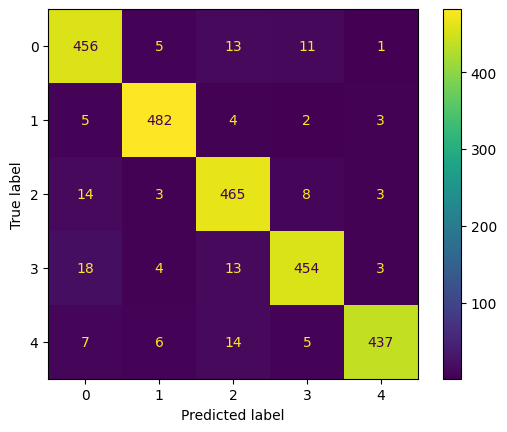

In [88]:
# Replace y_test, y_pred with your test variables

accuracy = accuracy_score(y_test_news, y_pred)
precision = precision_score(y_test_news, y_pred, average='macro')
recall = recall_score(y_test_news, y_pred, average='macro')
f1 = f1_score(y_test_news, y_pred, average='macro')
matrix = confusion_matrix(y_test_news, y_pred)
matrix_display = ConfusionMatrixDisplay(matrix)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
matrix_display.plot()

## **5. Implementing Naive Bayes using sklearn [15 Marks]**

In this section, you will compare your manual implementation with **scikit-learn**'s (`sklearn`) implementation of the Naive Bayes models we covered above.

[Scikit-learn](https://scikit-learn.org/stable/) (also called `sklearn`) is one of the most widely used machine learning libraries in Python. It provides:
- **Pre-built, efficient model classes** that you can directly import and use without writing the low-level code yourself.

- Tools for **training**, **testing**, and **evaluating** models.  

In sklearn, most models follow the same basic pattern:
1. **Import the model** you want to use.  

2. **Create an object** of that model class.

3. **Train the model** using the `.fit()` method (on your training data).  

4. **Make predictions** using the `.predict()` method (on your test data).  

5. **Evaluate performance** using metrics such as accuracy.  

For Naive Bayes, sklearn provides different variants depending on the type of data:
- [`BernoulliNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) – used when the features are binary

- [`MultinomialNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) – used when the features are discrete or represent counts.

**Your Task**  
1. Implement both `BernoulliNB` and `MultinomialNB` using sklearn on the same datasets you used for your manual implementation.  
2. Evaluate your models using the following metrics (code given — just replace the dummy variables):  
   - **Accuracy**, **Precision**, **Recall**, **F1-score**, **Confusion Matrix**  
3. Compare the performance of these sklearn models with your manual implementation.  

In [89]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB

### 5.1 Bernoulli Naive Bayes using sklearn [5 Marks]

In [90]:
# Code here for BernoulliNB (on golf data)
bnb_sklearn = BernoulliNB()
bnb_sklearn.fit(X_train, y_train)
y_pred = bnb_sklearn.predict(X_test)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[1123    0]
 [   0 1177]]


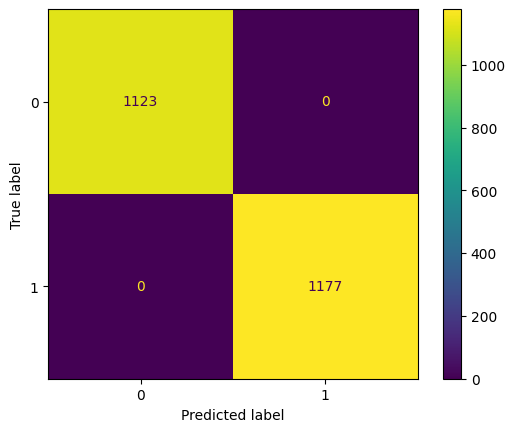

In [91]:
# Replace y_test, y_pred with your golf test variables

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
matrix_display = ConfusionMatrixDisplay(matrix)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
matrix_display.plot()
print(matrix)

### 5.2 Multinomial Naive Bayes using sklearn [5 Marks]

In [92]:
# Code here for MultinomialNB (on 20 Newsgroups data)

X_train_counts = [bow.vectorize(text) for text in X_train_news]
X_test_counts = [bow.vectorize(text) for text in X_test_news]

mnb_sklearn = MultinomialNB()
mnb_sklearn.fit(X_train_counts, y_train_news)

y_pred_news = mnb_sklearn.predict(X_test_counts)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[1123    0]
 [   0 1177]]


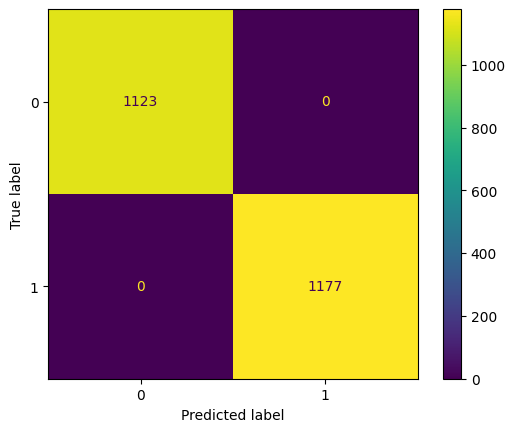

In [93]:
# Replace y_test, y_pred with your 20 Newsgroups test variables

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
matrix = confusion_matrix(y_test, y_pred)
matrix_display = ConfusionMatrixDisplay(matrix)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
matrix_display.plot()
print(matrix)

### 5.3 Conclusion [5 Marks]
Explain the key factors you considered when determining which dataset is more suitable for **Bernoulli Naive Bayes** and which is better suited for **Multinomial Naive Bayes**.

**Answer:**

## **6. Text Generation using Naive Bayes [5 marks]**

### 6.1 Shannon-Style Text Generation with Naive Bayes

So far, we have used **Multinomial Naive Bayes** as a *classifier*: given a text → predict the most likely **class**.  

But we can also flip the perspective: given a **class** → generate a sequence of words that "look like" that class.  

This idea goes back to **Claude Shannon (1948)**, who showed how to generate language-like sequences by **sampling symbols according to their probabilities**.  
<br>

### 6.2 Shannon's Algorithm (Simplified)
1. **Collect statistics**: estimate how often each symbol (word or character) appears.  

2. **Build probabilities**: compute the distribution of symbols.  

3. **Sample from the distribution**:  
   - At each step, randomly choose the next symbol according to its probability.  

   - More frequent symbols are more likely to appear, but rare ones can still show up.  

4. **Repeat** this process to generate longer sequences.  

The result may look like gibberish, but it reflects the *statistical flavor* of the original text.  
<br>

### 6.3 Connecting Shannon Generation to Naive Bayes
In our case, the "statistics" come from the **trained `MultinomialNB` model in scikit-learn**. For each class, the model stores `model.feature_log_prob_` → the probability of each word given that class.

By picking a class and sampling words from its probability distribution, we implement **Shannon's idea of random generation**.

For example:  

Class = `"rec.sport.baseball"`

High-probability words might be: `["game", "team", "season", "player", "pitch"]`  

Generated text could be: `player game team season pitch runs league baseball`  
<br>

### 6.4 Why is this important?
This experiment shows that even a simple classifier like Naive Bayes can be used *generatively*. It connects the historical Shannon method to modern GenAI: both rely on sampling from probability distributions. Advanced models (like ChatGPT) use the same principle, but with much richer probability structures and long-range context.
<br><br>
### 6.5 Shannon Generation in a function

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def shannon_generate(model, vocab, label_idx, n_words=10):
    """
    Generate random words from a trained MultinomialNB for a given class.

    Parameters
    ----------
    model : MultinomialNB
        A trained Naive Bayes model from scikit-learn.
    vocab : list
        The vocabulary list (mapping feature indices back to words).
    label_idx : int
        Index of the class label we want to generate text for.
    n_words : int
        Number of words to sample.

    Returns
    -------
    sampled_words : list
        List of generated words.
    probs : np.array
        Probability distribution of words for the chosen class.
    """

    # === Step 1: Get log-probabilities of words for the chosen class ===
    log_probs = model.feature_log_prob_[label_idx]

    # === Step 2: Convert log-probabilities back to normal probabilities ===
    probs = np.exp(log_probs)

    # === Step 3: Normalize (just in case, ensures they sum to 1) ===
    probs /= probs.sum()

    # === Step 4: Randomly sample words according to their probabilities ===
    # np.random.choice picks indices with probability proportional to probs
    sampled_idx = np.random.choice(len(vocab), size=n_words, p=probs)

    # === Step 5: Map sampled indices back to actual words from the vocab ===
    sampled_words = [vocab[i] for i in sampled_idx]

    return sampled_words, probs

### 6.6 Generating Words from Each Class

Study the `shannon_generate` function given above. Your job is to use it to **generate 10 random words per class** from the trained sklearn MultinomialNB model on the 20 Newsgroups data.  

Instructions:
1. Loop through all 5 classes of your model.  

2. For each class:
   - Call `shannon_generate(model, vocab, label_idx, n_words=10)`.
    
   - Print the class name and the 10 generated words.  

You should see that the generated words reflect the topic of each newsgroup (e.g., baseball terms for `rec.sport.baseball`, space/NASA terms for `sci.space`, etc.).

In [95]:
# Replace 'mnb' with your scikit-learn trained MultinomialNB
label_names = mnb_sklearn.classes_

# Code here
vocab = bow.vocab
for idx, cls in enumerate(mnb_sklearn.classes_):
    words, probs = shannon_generate(mnb_sklearn, vocab, idx, n_words=10)
    print(f"{cls}: " + " ".join(words))
# vocab = bow.vocab  # from your earlier BagOfWords
# for idx, cls in enumerate(mnb.classes_):
#     words, probs = shannon_generate(mnb, vocab, idx, n_words=10)
#     print(f"{cls}: " + " ".join(words))

comp.graphics: version well three product u 91 put recognize would including
rec.sport.baseball: 1 year 16 league hand scored two 50 given 4
sci.med: york taste increase someone bad pain thanks hospital really define
sci.space: somebody sometimes star sounds 21 years win lunar lots nasa
talk.politics.mideast: ira small soviet yet israeli number right jews soldiers long


In [96]:
# Code here

# Congratulations! 🥐
